# Auditoría de Datos: Inside Airbnb (Santiago, Chile)

> **Convención de nombres de DataFrames**  
> `df_raw` → datos tal como se descargan (nunca se modifica).  
> `df` → copia de trabajo para análisis. Las transformaciones destructivas solo ocurren en `df`.

In [2]:
import hashlib
import os
import re
import urllib.request

import folium
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# ── Semilla global para reproducibilidad ────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Estilo de gráficos ───────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

---
## Sección 1 · Ficha del dataset

### 1.1 Metadatos de origen

| Campo | Valor |
|---|---|
| **Fuente** | [Inside Airbnb](http://insideairbnb.com/get-the-data/) |
| **URL canónica** | `https://data.insideairbnb.com/chile/rm/santiago/2024-12-27/visualisations/listings.csv` |
| **Fecha de corte (snapshot)** | 27 de diciembre de 2024 |
| **Licencia del dataset** | Open Database License (ODbL) 1.0 |
| **Dominio** | Alojamiento / Turismo / Inmobiliario |
| **Dueño propuesto** | Equipo de Analítica del Ministerio de Vivienda y Urbanismo (MINVU) |
| **Columnas excluidas del análisis** | `neighbourhood_group` (vacía en Santiago), `license` (>99 % nulos) |

> La integridad del archivo se verifica automáticamente en la celda de carga mediante MD5.

---

### 1.2 Glosario de términos clave (12 términos)

| # | Campo | Tipo | ¿Permite nulos? | Rango / valores válidos | Ejemplo |
|---|---|---|---|---|---|
| 1 | `id` | int | No | > 0 | 12345 |
| 2 | `name` | string | Sí | Texto libre | "Depto céntrico Providencia" |
| 3 | `host_id` | int | No | > 0 | 98765 |
| 4 | `host_name` | string | Sí | Texto libre | "María" |
| 5 | `neighbourhood` | string | No | Comunas de Santiago | "Providencia" |
| 6 | `latitude` | float | No | −33.7 a −33.3 | −33.4372 |
| 7 | `longitude` | float | No | −70.9 a −70.4 | −70.6506 |
| 8 | `room_type` | string | No | Entire home/apt, Private room, Shared room, Hotel room | "Entire home/apt" |
| 9 | `price` | float | No | > 0 (CLP) | 45000.0 |
| 10 | `minimum_nights` | int | No | ≥ 1 | 2 |
| 11 | `number_of_reviews` | int | No | ≥ 0 | 34 |
| 12 | `availability_365` | int | No | 0 – 365 (días/año disponibles) | 180 |

In [3]:
# ── Descarga y verificación de integridad ───────────────────────────────────
URL      = "https://data.insideairbnb.com/chile/rm/santiago/2024-12-27/visualisations/listings.csv"
FILENAME = "listings.csv"

if not os.path.exists(FILENAME):
    print("Descargando dataset...")
    urllib.request.urlretrieve(URL, FILENAME)
    print("Descarga completada.")
else:
    print("Archivo ya existe localmente.")

# Hash MD5 para trazabilidad del snapshot
md5 = hashlib.md5(open(FILENAME, "rb").read()).hexdigest()
print(f"MD5 del archivo : {md5}")
print(f"Tamaño          : {os.path.getsize(FILENAME):,} bytes")

# ── Carga — df_raw nunca se modifica ────────────────────────────────────────
df_raw = pd.read_csv(FILENAME, parse_dates=["last_review"])

# Columnas excluidas justificadas
COLS_EXCLUIDAS = ["license", "neighbourhood_group"]
df_raw = df_raw.drop(columns=COLS_EXCLUIDAS)

print(f"\nDimensiones df_raw: {df_raw.shape}")
display(df_raw.head(3))

Archivo ya existe localmente.
MD5 del archivo : 95e575d4284dbe8025095c0a0f3d9e82
Tamaño          : 2,330,025 bytes

Dimensiones df_raw: (15051, 16)


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,65058,Dpto amoblado centro historico,318016,Patricio,Recoleta,-33.43049,-70.64079,Private room,NaN,2,0,NaT,NaN,1,0,0
1,73752,Barrio Lastarria,374124,Daniela&Ricardo,Santiago,-33.43865,-70.64241,Private room,NaN,3,0,NaT,NaN,1,0,0
2,80482,Room Private for Woman,154527,Jacqueline,La Florida,-33.51922,-70.59152,Private room,NaN,2,0,NaT,NaN,1,0,0


---
## Sección 2 · Calidad

Se evalúan cinco dimensiones: **completitud, unicidad, validez, consistencia y oportunidad**.

Filas totales : 15,051
Filas completas (sin ningún nulo): 10,717 (71.2 %)


,Nulos,Porcentaje (%)
last_review,3244,21.55
reviews_per_month,3244,21.55
price,1989,13.22


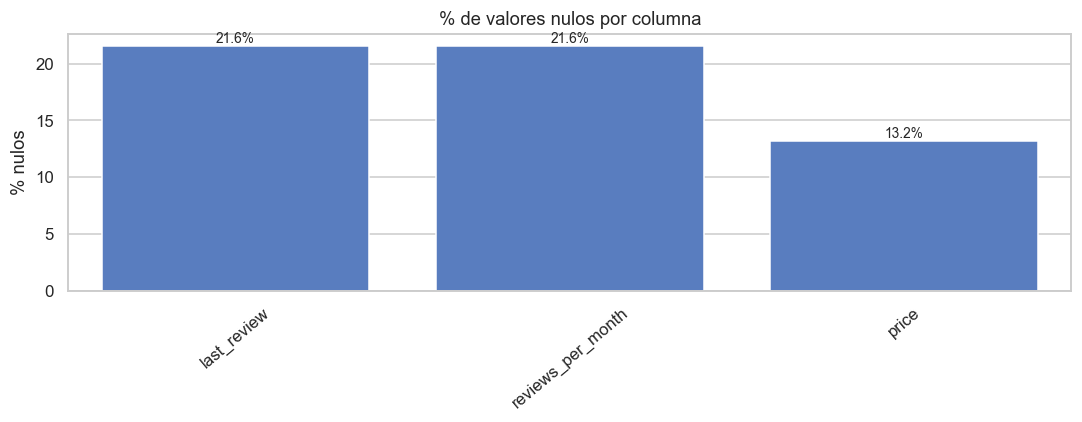

In [4]:
# ── 2.1 Completitud ─────────────────────────────────────────────────────────
missing      = df_raw.isnull().sum()
missing_pct  = (missing / len(df_raw) * 100).round(2)
completitud  = pd.DataFrame({"Nulos": missing, "Porcentaje (%)": missing_pct})
completitud_nz = completitud[completitud["Nulos"] > 0].sort_values("Porcentaje (%)", ascending=False)

print(f"Filas totales : {len(df_raw):,}")
print(f"Filas completas (sin ningún nulo): {df_raw.dropna().shape[0]:,} "
      f"({df_raw.dropna().shape[0]/len(df_raw)*100:.1f} %)")
display(completitud_nz)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=completitud_nz.index, y=completitud_nz["Porcentaje (%)"], ax=ax)
ax.set_title("% de valores nulos por columna")
ax.set_ylabel("% nulos")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=40)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
# ── 2.2 Unicidad ────────────────────────────────────────────────────────────
dup_filas = df_raw.duplicated().sum()
dup_ids   = df_raw.duplicated(subset=["id"]).sum()

print(f"Filas duplicadas (completas) : {dup_filas}")
print(f"IDs de anuncio duplicados    : {dup_ids}")

Filas duplicadas (completas) : 0
IDs de anuncio duplicados    : 0


In [6]:
# ── 2.3 Validez ─────────────────────────────────────────────────────────────
# Bounding box aproximado de la Región Metropolitana de Santiago
LAT_MIN, LAT_MAX = -33.75, -33.25
LON_MIN, LON_MAX = -70.95, -70.40
SNAPSHOT_DATE   = pd.Timestamp("2024-12-27")

checks = {
    "price ≤ 0"                          : (df_raw["price"] <= 0).sum(),
    "minimum_nights ≤ 0"                 : (df_raw["minimum_nights"] <= 0).sum(),
    "availability_365 fuera [0,365]"     : (~df_raw["availability_365"].between(0, 365)).sum(),
    "reviews_per_month < 0"              : (df_raw["reviews_per_month"] < 0).sum(),
    "latitude fuera bounding box"        : (~df_raw["latitude"].between(LAT_MIN, LAT_MAX)).sum(),
    "longitude fuera bounding box"       : (~df_raw["longitude"].between(LON_MIN, LON_MAX)).sum(),
    "last_review > fecha snapshot"       : (df_raw["last_review"] > SNAPSHOT_DATE).sum(),
}

validez_df = pd.DataFrame(
    [(regla, n, f"{n/len(df_raw)*100:.3f} %") for regla, n in checks.items()],
    columns=["Regla de validez", "Filas inválidas", "% del total"]
)
display(validez_df)

,Regla de validez,Filas inválidas,% del total
0,price ≤ 0,0,0.000 %
1,minimum_nights ≤ 0,0,0.000 %
2,"availability_365 fuera [0,365]",0,0.000 %
3,reviews_per_month < 0,0,0.000 %
4,latitude fuera bounding box,1,0.007 %
5,longitude fuera bounding box,578,3.840 %
6,last_review > fecha snapshot,0,0.000 %


In [7]:
# ── 2.4 Consistencia ────────────────────────────────────────────────────────
# Regla: si number_of_reviews == 0  →  last_review y reviews_per_month deben ser nulos
sin_reviews = df_raw[df_raw["number_of_reviews"] == 0]
c1 = sin_reviews["last_review"].notna().sum()
c2 = sin_reviews["reviews_per_month"].notna().sum()

# Regla: calculated_host_listings_count ≥ 1 para cualquier fila presente
c3 = (df_raw["calculated_host_listings_count"] < 1).sum()

consistencia_df = pd.DataFrame([
    ("number_of_reviews=0 pero last_review no nulo",       c1, f"{c1/len(df_raw)*100:.2f} %"),
    ("number_of_reviews=0 pero reviews_per_month no nulo", c2, f"{c2/len(df_raw)*100:.2f} %"),
    ("calculated_host_listings_count < 1",                 c3, f"{c3/len(df_raw)*100:.2f} %"),
], columns=["Regla de consistencia", "Filas incoherentes", "% del total"])

display(consistencia_df)

,Regla de consistencia,Filas incoherentes,% del total
0,number_of_reviews=0 pero last_review no nulo,0,0.00 %
1,number_of_reviews=0 pero reviews_per_month no ...,0,0.00 %
2,calculated_host_listings_count < 1,0,0.00 %


Anuncios sin ninguna reseña (last_review nulo)      : 3,244 (21.6 %)
Anuncios sin actividad en últimos 12 meses          : 1,720 (11.4 %)
Anuncios sin actividad en últimos 24 meses          : 1,023 (6.8 %)


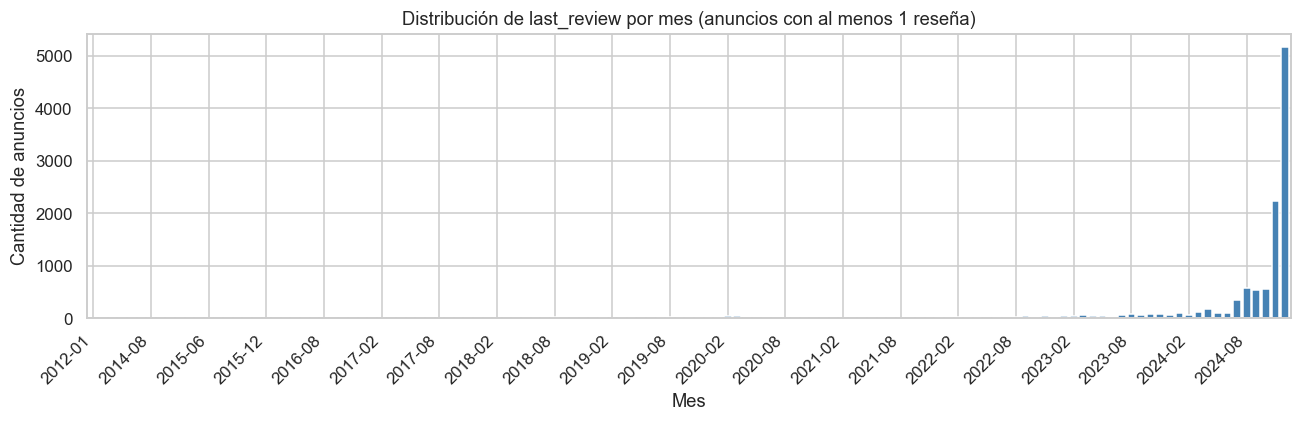

In [8]:
# ── 2.5 Oportunidad (Timeliness) ────────────────────────────────────────────
df_lr = df_raw["last_review"].dropna().copy()

# Antigüedad respecto al snapshot
meses_antiguedad = ((SNAPSHOT_DATE - df_lr) / pd.Timedelta(days=30)).round(1)

sin_actividad_12m = (meses_antiguedad > 12).sum()
sin_actividad_24m = (meses_antiguedad > 24).sum()
nunca_revisado    = df_raw["last_review"].isna().sum()

print(f"Anuncios sin ninguna reseña (last_review nulo)      : {nunca_revisado:,} ({nunca_revisado/len(df_raw)*100:.1f} %)")
print(f"Anuncios sin actividad en últimos 12 meses          : {sin_actividad_12m:,} ({sin_actividad_12m/len(df_raw)*100:.1f} %)")
print(f"Anuncios sin actividad en últimos 24 meses          : {sin_actividad_24m:,} ({sin_actividad_24m/len(df_raw)*100:.1f} %)")

# Histograma de last_review por mes
fig, ax = plt.subplots(figsize=(12, 4))
df_lr_mensual = df_lr.dt.to_period("M").value_counts().sort_index()
df_lr_mensual.index = df_lr_mensual.index.astype(str)
df_lr_mensual.plot(kind="bar", ax=ax, color="steelblue", width=0.8)
ax.set_title("Distribución de last_review por mes (anuncios con al menos 1 reseña)")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de anuncios")
# mostrar solo cada 6 meses para no saturar el eje x
ticks = list(range(0, len(df_lr_mensual), 6))
ax.set_xticks(ticks)
ax.set_xticklabels([df_lr_mensual.index[i] for i in ticks], rotation=45, ha="right")
plt.tight_layout()
plt.show()

Filas eliminadas por dropna selectivo: 0 (0.00 %)
Filas en df_raw: 15,051  →  Filas en df: 15,051


,Dimensión,Métrica,Valor,Umbral,Estado
0,Completitud,% filas completamente completas (df_raw),71.2 %,≥ 80 %,⚠️
1,Unicidad,Filas duplicadas,0,0,✅
2,Unicidad,IDs duplicados,0,0,✅
3,Validez,Precios ≤ 0,0,0,✅
4,Validez,Coords fuera de Santiago,1,0,⚠️
5,Consistencia,number_of_reviews=0 con last_review no nulo,0,0,✅
6,Oportunidad,% anuncios sin actividad >12 meses,11.4 %,< 30 %,✅


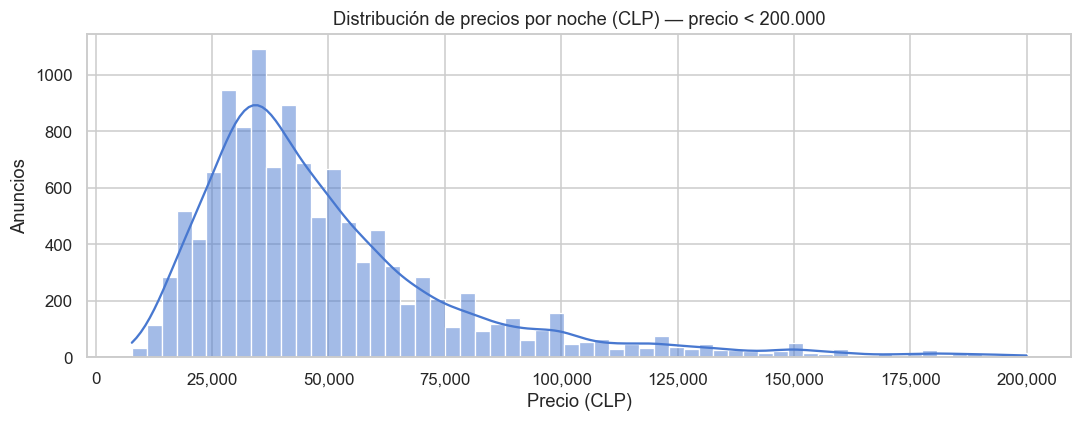

In [9]:
# ── 2.6 Estrategia de limpieza y tabla resumen ──────────────────────────────
# Los nulos se concentran en last_review y reviews_per_month:
# ambos son nulos cuando un anuncio nunca recibió reseñas (MAR, no MCAR).
# Decisión: imputar reviews_per_month con 0 cuando number_of_reviews == 0;
# mantener last_review como NaT (es informativo que no haya fecha).
# Solo se eliminan filas con nulos en columnas sin patrón claro.

df = df_raw.copy()
df["reviews_per_month"] = df["reviews_per_month"].fillna(
    df["number_of_reviews"].apply(lambda x: 0.0 if x == 0 else np.nan)
)
# Tras imputación, las filas con reviews_per_month aún nulas son anuncios
# con reseñas pero sin tasa mensual calculada → se eliminan (son pocas)
filas_antes = len(df)
df = df.dropna(subset=["reviews_per_month"]).copy()
filas_despues = len(df)
print(f"Filas eliminadas por dropna selectivo: {filas_antes - filas_despues} "
      f"({(filas_antes-filas_despues)/filas_antes*100:.2f} %)")
print(f"Filas en df_raw: {len(df_raw):,}  →  Filas en df: {len(df):,}")

# ── Tabla resumen de calidad ─────────────────────────────────────────────────
resumen_calidad = pd.DataFrame([
    ("Completitud",  "% filas completamente completas (df_raw)",
     f"{df_raw.dropna().shape[0]/len(df_raw)*100:.1f} %", "≥ 80 %",
     "⚠️" if df_raw.dropna().shape[0]/len(df_raw) < 0.8 else "✅"),
    ("Unicidad",     "Filas duplicadas",
     str(dup_filas), "0",
     "✅" if dup_filas == 0 else "❌"),
    ("Unicidad",     "IDs duplicados",
     str(dup_ids), "0",
     "✅" if dup_ids == 0 else "❌"),
    ("Validez",      "Precios ≤ 0",
     str(checks["price ≤ 0"]), "0",
     "✅" if checks["price ≤ 0"] == 0 else "❌"),
    ("Validez",      "Coords fuera de Santiago",
     str(checks["latitude fuera bounding box"]), "0",
     "✅" if checks["latitude fuera bounding box"] == 0 else "⚠️"),
    ("Consistencia", "number_of_reviews=0 con last_review no nulo",
     str(c1), "0",
     "✅" if c1 == 0 else "⚠️"),
    ("Oportunidad",  "% anuncios sin actividad >12 meses",
     f"{sin_actividad_12m/len(df_raw)*100:.1f} %", "< 30 %",
     "✅" if sin_actividad_12m/len(df_raw) < 0.30 else "⚠️"),
], columns=["Dimensión", "Métrica", "Valor", "Umbral", "Estado"])

display(resumen_calidad)

# Distribución de precios (df limpio)
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df[df["price"] < 200_000]["price"], bins=60, kde=True, ax=ax)
ax.set_title("Distribución de precios por noche (CLP) — precio < 200.000")
ax.set_xlabel("Precio (CLP)")
ax.set_ylabel("Anuncios")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

---
## Sección 3 · Sensibilidad y PII

### 3.1 Clasificación por columna

Taxonomía basada en ISO 27001 Anexo A / NIST SP 800-188:

| Columna | Nivel | Justificación |
|---|---|---|
| `id` | Pública | Identificador del anuncio, sin vinculación directa a persona |
| `neighbourhood` | Pública | Granularidad comunal, pública por diseño |
| `room_type` | Pública | Categoría agregada |
| `price` | Pública | Precio público del anuncio |
| `minimum_nights` | Pública | Política pública del anuncio |
| `number_of_reviews` | Pública | Métrica agregada |
| `availability_365` | Pública | Disponibilidad pública |
| `calculated_host_listings_count` | Pública | Conteo agregado |
| `number_of_reviews_ltm` | Pública | Métrica agregada |
| `last_review` | Interna | Fecha de actividad; revela patrones de uso |
| `reviews_per_month` | Interna | Métrica derivada; revela frecuencia de uso |
| `name` | Confidencial | Texto libre; puede contener dirección, teléfono o correo |
| `host_id` | **Restringida / PII indirecta** | Permite cruzar con API pública de Airbnb para obtener perfil completo del anfitrión |
| `host_name` | **Restringida / PII directa** | Nombre de persona física; facilita linkage con Conservador de Bienes Raíces |
| `latitude` | **Restringida / PII indirecta** | Coordenada a 6 decimales → precisión ~10 cm; re-identifica propiedad |
| `longitude` | **Restringida / PII indirecta** | Ídem `latitude` |

### 3.2 Detección automática de PII en texto libre

In [10]:
# ── Patrones PII para Chile ──────────────────────────────────────────────────
patterns = {
    # Teléfono chileno: +56 9 XXXX XXXX  |  9XXXXXXXX  |  56-9-XXXX-XXXX
    "teléfono_cl" : r"(?:\+?56[\s\-]?)?(?:9[\s\-]?\d{4}[\s\-]?\d{4}|\d{2}[\s\-]?\d{3}[\s\-]?\d{4})",
    # Correo electrónico
    "email"       : r"[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}",
    # RUT chileno: 12.345.678-9 | 12345678-9 | 12345678K
    "rut_cl"      : r"\b\d{1,2}\.?\d{3}\.?\d{3}[\-]?[\dKk]\b",
    # Instagram/WhatsApp handle
    "social_handle": r"@[A-Za-z0-9_.]{3,}",
    # Dirección (calle + número)
    "direccion"   : r"(?:Av(?:enida)?\.?|Calle|Pasaje|Psje\.?)\s+[A-ZÁÉÍÓÚÑ][a-záéíóúñ]+(?:\s+[A-ZÁÉÍÓÚÑ][a-záéíóúñ]+)*\s+\d+",
}

col_texto = df["name"].fillna("")
pii_resultados = []
for label, pat in patterns.items():
    n = col_texto.str.contains(pat, flags=re.IGNORECASE, na=False).sum()
    pii_resultados.append((label, n, f"{n/len(df)*100:.3f} %"))

pii_df = pd.DataFrame(pii_resultados, columns=["Tipo de PII", "Filas detectadas", "% del total"])
display(pii_df)

# Precisión geográfica de las coordenadas
# > 4 decimales → precisión < 10 m → re-identificación de propiedad probable
decimales_lat = df["latitude"].apply(lambda x: len(str(x).split(".")[1]) if "." in str(x) else 0)
alta_precision = (decimales_lat > 4).sum()
print(f"\nAnuncios con latitud a >4 decimales (precisión <10 m): {alta_precision:,} "
      f"({alta_precision/len(df)*100:.1f} %)")

,Tipo de PII,Filas detectadas,% del total
0,teléfono_cl,0,0.000 %
1,email,0,0.000 %
2,rut_cl,0,0.000 %
3,social_handle,2,0.013 %
4,direccion,4,0.027 %



Anuncios con latitud a >4 decimales (precisión <10 m): 14,134 (93.9 %)


---
## Sección 4 · k-anonymity

### 4.1 Selección y justificación de cuasi-identificadores (QIDs)

Un atacante externo con acceso a datos públicos puede conocer sobre un anuncio:
- La **comuna** donde se ubica (basta buscar en Google Maps o la plataforma).
- El **tipo de cuarto** (visible en Airbnb).
- El **rango de noches mínimas** (visible en Airbnb).

Por ello los QIDs son: `neighbourhood`, `room_type`, `minimum_nights`.

**Umbral objetivo:** k ≥ 5 (estándar práctico; HIPAA usa k ≥ 5 para registros de salud, adoptado aquí por analogía).

QIDs                        : ['neighbourhood', 'room_type', 'minimum_nights']
k mínimo                    : 1
k mediana                   : 2.0
k P25 / P75                 : 1.0 / 9.0
Clases con k < 5 (umbral)   : 387 / 588 (65.8 %)
Registros con k = 1         : 228 (1.5 %)
Registros con k < 5 (umbral) : 668 (4.4 %)


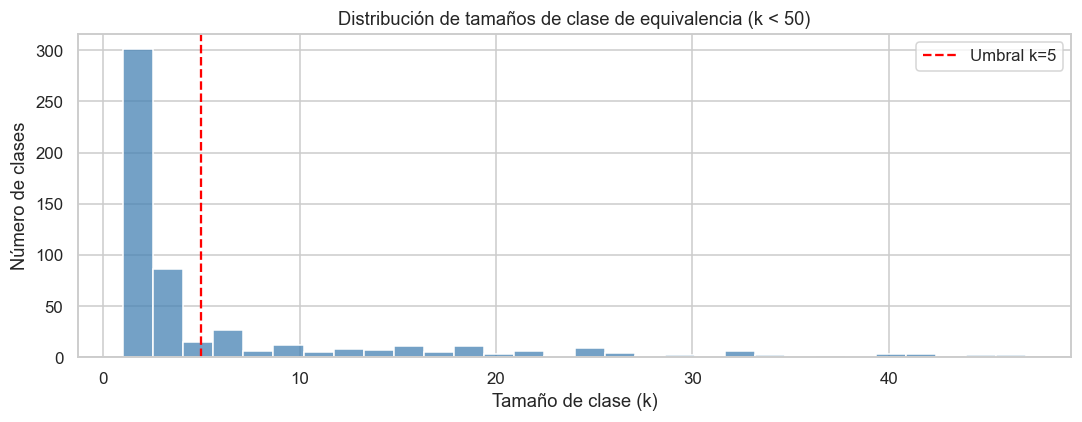


Ejemplos de clases con k=1 (alto riesgo):


,neighbourhood,room_type,minimum_nights,k_size
0,Cerrillos,Entire home/apt,1,1
2,Cerrillos,Entire home/apt,3,1
3,Cerrillos,Entire home/apt,12,1
5,Cerrillos,Private room,2,1
6,Cerrillos,Private room,4,1
7,Cerrillos,Shared room,1,1
9,Cerro Navia,Private room,1,1
11,Cerro Navia,Private room,30,1
15,Conchalí,Shared room,1,1
17,El Bosque,Entire home/apt,6,1


In [11]:
# ── 4.2 Cálculo de clases de equivalencia ───────────────────────────────────
QIDS = ["neighbourhood", "room_type", "minimum_nights"]
K_TARGET = 5

k_clases = (
    df.groupby(QIDS, observed=True)
    .size()
    .reset_index(name="k_size")
)

k_min    = k_clases["k_size"].min()
k_median = k_clases["k_size"].median()
k_p25    = k_clases["k_size"].quantile(0.25)
k_p75    = k_clases["k_size"].quantile(0.75)

# Registros en riesgo (no solo clases)
k_clases_merged = df.merge(k_clases, on=QIDS, how="left")
registros_k1  = (k_clases_merged["k_size"] == 1).sum()
registros_lt5 = (k_clases_merged["k_size"] < K_TARGET).sum()

clases_lt5    = (k_clases["k_size"] < K_TARGET).sum()
clases_total  = len(k_clases)

print(f"QIDs                        : {QIDS}")
print(f"k mínimo                    : {k_min}")
print(f"k mediana                   : {k_median}")
print(f"k P25 / P75                 : {k_p25} / {k_p75}")
print(f"Clases con k < {K_TARGET} (umbral)   : {clases_lt5} / {clases_total} ({clases_lt5/clases_total*100:.1f} %)")
print(f"Registros con k = 1         : {registros_k1:,} ({registros_k1/len(df)*100:.1f} %)")
print(f"Registros con k < {K_TARGET} (umbral) : {registros_lt5:,} ({registros_lt5/len(df)*100:.1f} %)")

# Distribución
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(k_clases[k_clases["k_size"] < 50]["k_size"],
             bins=30, kde=False, ax=ax, color="steelblue")
ax.axvline(K_TARGET, color="red", linestyle="--", label=f"Umbral k={K_TARGET}")
ax.set_title("Distribución de tamaños de clase de equivalencia (k < 50)")
ax.set_xlabel("Tamaño de clase (k)")
ax.set_ylabel("Número de clases")
ax.legend()
plt.tight_layout()
plt.show()

# Ejemplos de clases k=1
print("\nEjemplos de clases con k=1 (alto riesgo):")
display(k_clases[k_clases["k_size"] == 1].head(10))

Clases con l-diversity = 1 en room_type: 588 / 588 (100.0 %)
→ En estas clases, conocer commune + room_type + min_nights basta para
  inferir el tipo de alojamiento incluso si k > 1.


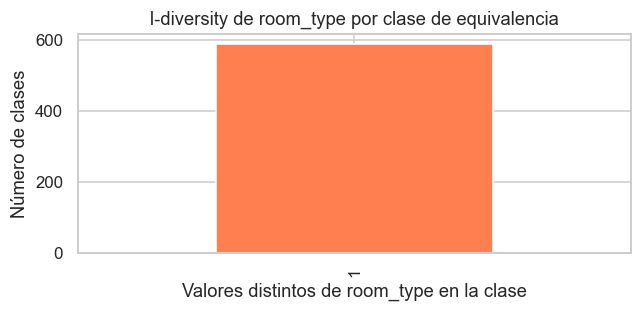

In [12]:
# ── 4.3 l-diversity sobre room_type ─────────────────────────────────────────
# k-anonymity es vulnerable a ataques de homogeneidad:
# si todos los registros de una clase tienen el mismo room_type, el atributo
# sensible es trivialmente inferible aunque k > 1.
# Calculamos la diversidad de room_type dentro de cada clase de equivalencia.

l_div = (
    df.groupby(QIDS, observed=True)["room_type"]
    .nunique()
    .reset_index(name="l_room_type")
)

l1_clases = (l_div["l_room_type"] == 1).sum()
print(f"Clases con l-diversity = 1 en room_type: {l1_clases} / {len(l_div)} "
      f"({l1_clases/len(l_div)*100:.1f} %)")
print("→ En estas clases, conocer commune + room_type + min_nights basta para")
print("  inferir el tipo de alojamiento incluso si k > 1.")

fig, ax = plt.subplots(figsize=(6, 3))
l_div["l_room_type"].value_counts().sort_index().plot(kind="bar", ax=ax, color="coral")
ax.set_title("l-diversity de room_type por clase de equivalencia")
ax.set_xlabel("Valores distintos de room_type en la clase")
ax.set_ylabel("Número de clases")
plt.tight_layout()
plt.show()

---
## Sección 5 · Mini-ejercicio exploratorio — Ataque de re-identificación

### Descripción del ataque

El dataset publicado incluye **coordenadas precisas** (hasta 6 decimales, ~10 cm de precisión) y el **nombre de pila del anfitrión**. Con ambos datos un atacante puede:

1. **Geocodificación inversa**: convertir `(latitude, longitude)` → dirección física (herramientas: Nominatim/OpenStreetMap, Google Maps, Bing Maps).  
2. **Linkage con registro civil de propiedades**: buscar `host_name` + dirección en el [Conservador de Bienes Raíces de Chile](https://conservadorchile.com/buscar-propiedad-por-nombre-propietario/) para obtener nombre completo, RUT, hipotecas y tasación.  
3. **Amplificación**: con el RUT, cruzar con SII, CMFCHILE, o redes sociales para construir un perfil completo.

La celda de abajo ejecuta los pasos 1 y 2 con **datos sintéticos** (coordenadas ficticias) para demostrar la mecánica sin exponer datos reales.

In [13]:
# ── 5.1 Cuantificación del riesgo geográfico ─────────────────────────────────
decimales = df["latitude"].apply(
    lambda x: len(str(abs(x)).split(".")[1]) if "." in str(abs(x)) else 0
)

precision_map = {
    0: "~111 km", 1: "~11 km", 2: "~1.1 km",
    3: "~110 m",  4: "~11 m", 5: "~1.1 m",
    6: "~11 cm"
}

prec_dist = decimales.value_counts().sort_index().rename("Anuncios")
prec_dist = prec_dist.reset_index()
prec_dist.columns = ["Decimales latitud", "Anuncios"]
prec_dist["Precisión aprox."] = prec_dist["Decimales latitud"].map(precision_map)
prec_dist["%"] = (prec_dist["Anuncios"] / len(df) * 100).round(2)
display(prec_dist)

# ── 5.2 Demostración del ataque con registro sintético ───────────────────────
print("\n─── Demostración con datos SINTÉTICOS (no son datos reales) ───")

# Registro ficticio que ilustra el ataque
victima_sintetica = {
    "id": 99999999,
    "host_name": "Carlos",          # nombre de pila conocido
    "latitude" : -33.4326847,       # 7 decimales → ~1 cm
    "longitude": -70.6103482,
    "neighbourhood": "Ñuñoa",
    "room_type": "Entire home/apt",
}

print(f"  Anuncio ID     : {victima_sintetica['id']}")
print(f"  Host name      : {victima_sintetica['host_name']}")
print(f"  Coordenadas    : ({victima_sintetica['latitude']}, {victima_sintetica['longitude']})")
print(f"  Decimales lat  : {len(str(abs(victima_sintetica['latitude'])).split('.')[1])} → precisión ~1 cm")

# URL de geocodificación inversa (Nominatim — no requiere API key)
nominatim_url = (
    f"https://nominatim.openstreetmap.org/reverse"
    f"?lat={victima_sintetica['latitude']}&lon={victima_sintetica['longitude']}"
    f"&format=json"
)
print(f"\n  Paso 1 — Geocodificación inversa (ejecutar en navegador):")
print(f"  {nominatim_url}")
print(f"\n  Paso 2 — Linkage con Conservador de Bienes Raíces:")
print(f"  https://conservadorchile.com/buscar-propiedad-por-nombre-propietario/")
print(f"  Buscar: '{victima_sintetica['host_name']}' + dirección obtenida en paso 1")
print(f"\n  Resultado esperado: nombre completo, RUT, folio de propiedad, hipotecas.")
print(f"\n  → Con {alta_precision:,} anuncios a >4 decimales ({alta_precision/len(df)*100:.0f} % del dataset),")
print(f"    el ataque es replicable a escala masiva.")

# ── 5.3 Mapa de muestra (Santiago Centro) ────────────────────────────────────
sample = df[df["neighbourhood"] == "Santiago"].head(50)

if not sample.empty:
    m = folium.Map(
        location=[sample["latitude"].mean(), sample["longitude"].mean()],
        zoom_start=14
    )
    for _, row in sample.iterrows():
        popup = (
            f"<b>Host:</b> {row['host_name']}<br>"
            f"<b>Precio:</b> ${row['price']:,.0f} CLP<br>"
            f"<b>ID:</b> {row['id']}<br>"
            f"<b>Coords:</b> {row['latitude']:.6f}, {row['longitude']:.6f}"
        )
        folium.CircleMarker(
            location=(row["latitude"], row["longitude"]),
            radius=5, popup=folium.Popup(popup, max_width=250),
            color="crimson", fill=True, fill_opacity=0.7
        ).add_to(m)
    # Guardar como HTML adjunto para reproducibilidad offline
    m.save("mapa_ataque_santiago.html")
    print("\nMapa guardado en mapa_ataque_santiago.html")
    display(m)
else:
    print("Sin datos para la comuna 'Santiago' tras la limpieza.")

,Decimales latitud,Anuncios,Precisión aprox.,%
0,1,2,~11 km,0.01
1,2,8,~1.1 km,0.05
2,3,72,~110 m,0.48
3,4,835,~11 m,5.55
4,5,8277,~1.1 m,54.99
5,6,450,~11 cm,2.99
6,7,2916,NaN,19.37
7,8,1,NaN,0.01
8,11,2,NaN,0.01
9,12,13,NaN,0.09



─── Demostración con datos SINTÉTICOS (no son datos reales) ───
  Anuncio ID     : 99999999
  Host name      : Carlos
  Coordenadas    : (-33.4326847, -70.6103482)
  Decimales lat  : 7 → precisión ~1 cm

  Paso 1 — Geocodificación inversa (ejecutar en navegador):
  https://nominatim.openstreetmap.org/reverse?lat=-33.4326847&lon=-70.6103482&format=json

  Paso 2 — Linkage con Conservador de Bienes Raíces:
  https://conservadorchile.com/buscar-propiedad-por-nombre-propietario/
  Buscar: 'Carlos' + dirección obtenida en paso 1

  Resultado esperado: nombre completo, RUT, folio de propiedad, hipotecas.

  → Con 14,134 anuncios a >4 decimales (94 % del dataset),
    el ataque es replicable a escala masiva.

Mapa guardado en mapa_ataque_santiago.html


---
## Sección 6 · Plan de remediación

Las medidas se ordenan por **nivel de riesgo** y están vinculadas a los hallazgos cuantitativos de las secciones anteriores.

In [16]:
# ── 6.1 Tabla de remediación priorizada ──────────────────────────────────────
plan = pd.DataFrame([
    ("host_name",   "Alto",  "Suprimir",
     "PII directa; facilita linkage con Conservador (§3, §5)",
     "Inmediato", "Equipo de datos"),
    ("latitude / longitude", "Alto", "Truncar a 2 decimales (~1 km) o eliminar",
     f"{alta_precision/len(df)*100:.0f} % de anuncios a >4 decimales → re-id física (§5)",
     "Inmediato", "Ingeniería"),
    ("host_id",     "Medio", "Hash SHA-256 + sal privada",
     "PII indirecta; permite cruzar con API pública de Airbnb (§3)",
     "1 sprint", "Seguridad"),
    ("name",        "Medio", "Filtrar PII detectada; suprimir si ratio > 0",
     "Texto libre con posibles teléfonos, correos, RUT (§3)",
     "1 sprint", "Datos + Legal"),
    ("minimum_nights", "Bajo", "Generalizar en rangos (1, 2–3, 4–7, 8–30, >30)",
     f"Mejora k: {registros_lt5/len(df)*100:.0f} % de registros tienen k<{K_TARGET} (§4)",
     "Próxima versión", "Datos"),
    ("price",       "Bajo",  "Generalizar en bandas de CLP 10.000",
     "Reduce poder discriminatorio del QID precio (§4)",
     "Próxima versión", "Datos"),
], columns=["Columna", "Riesgo", "Acción", "Justificación (referencia)", "Plazo", "Responsable"])

display(plan)

,Columna,Riesgo,Acción,Justificación (referencia),Plazo,Responsable
0,host_name,Alto,Suprimir,PII directa; facilita linkage con Conservador ...,Inmediato,Equipo de datos
1,latitude / longitude,Alto,Truncar a 2 decimales (~1 km) o eliminar,94 % de anuncios a >4 decimales → re-id física...,Inmediato,Ingeniería
2,host_id,Medio,Hash SHA-256 + sal privada,PII indirecta; permite cruzar con API pública ...,1 sprint,Seguridad
3,name,Medio,Filtrar PII detectada; suprimir si ratio > 0,"Texto libre con posibles teléfonos, correos, R...",1 sprint,Datos + Legal
4,minimum_nights,Bajo,"Generalizar en rangos (1, 2–3, 4–7, 8–30, >30)",Mejora k: 4 % de registros tienen k<5 (§4),Próxima versión,Datos
5,price,Bajo,Generalizar en bandas de CLP 10.000,Reduce poder discriminatorio del QID precio (§4),Próxima versión,Datos


In [ ]:
# ── 6.2 Aplicar remediación y re-evaluar k-anonymity ────────────────────────
df_pub = df.copy()

# Supresión
df_pub = df_pub.drop(columns=["host_name", "host_id", "name",
                               "has_phone_in_name", "has_email_in_name"],
                     errors="ignore")

# Generalización geográfica: truncar a 2 decimales
df_pub["latitude"]  = df_pub["latitude"].round(2)
df_pub["longitude"] = df_pub["longitude"].round(2)

# Generalización de minimum_nights
def bin_nights(n):
    if n == 1:       return "1"
    elif n <= 3:     return "2-3"
    elif n <= 7:     return "4-7"
    elif n <= 30:    return "8-30"
    else:            return ">30"

df_pub["minimum_nights_bin"] = df_pub["minimum_nights"].apply(bin_nights)
df_pub = df_pub.drop(columns=["minimum_nights"])

# Re-evaluar k-anonymity con QIDs generalizados
QIDS_POST = ["neighbourhood", "room_type", "minimum_nights_bin"]

k_post = (
    df_pub.groupby(QIDS_POST, observed=True)
    .size()
    .reset_index(name="k_size")
)
k_post_merged = df_pub.merge(k_post, on=QIDS_POST, how="left")

registros_lt5_post = (k_post_merged["k_size"] < K_TARGET).sum()
k_min_post = k_post["k_size"].min()

print("── Comparación antes / después de la remediación ──")
comparacion = pd.DataFrame([
    ("k mínimo",
     str(k_min), str(k_min_post)),
    (f"Registros con k < {K_TARGET} (%)",
     f"{registros_lt5/len(df)*100:.1f} %",
     f"{registros_lt5_post/len(df_pub)*100:.1f} %"),
    ("Columnas con PII directa",
     "host_name, latitude*, longitude*",
     "Suprimidas / generalizadas"),
], columns=["Métrica", "Antes", "Después"])
display(comparacion)

print(f"\nColumnas del dataset público resultante:")
print(list(df_pub.columns))
print(f"\nFilas: {len(df_pub):,}   Columnas: {df_pub.shape[1]}")

# Análisis que siguen siendo posibles tras la remediación
print("""
── Utilidad analítica tras la remediación ──
Estudios de tendencias de precio por comuna y tipo de cuarto
Análisis de disponibilidad y estacionalidad por barrio
Comparativas de ocupación (reviews_per_month) por zona
Planificación urbana a nivel comunal
Geocodificación exacta de propiedades individuales (coordenadas truncadas)
Seguimiento de carteras de un mismo anfitrión entre plataformas (host_id suprimido)
""")

── Comparación antes / después de la remediación ──


,Métrica,Antes,Después
0,k mínimo,1,1
1,Registros con k < 5 (%),4.4 %,1.4 %
2,Columnas con PII directa,"host_name, latitude*, longitude*",Suprimidas / generalizadas



Columnas del dataset público resultante:
['id', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'minimum_nights_bin']

Filas: 15,051   Columnas: 13

── Utilidad analítica tras la remediación ──
✅ Estudios de tendencias de precio por comuna y tipo de cuarto
✅ Análisis de disponibilidad y estacionalidad por barrio
✅ Comparativas de ocupación (reviews_per_month) por zona
✅ Planificación urbana a nivel comunal
❌ Geocodificación exacta de propiedades individuales (coordenadas truncadas)
❌ Seguimiento de carteras de un mismo anfitrión entre plataformas (host_id suprimido)

